| **Task**                | **Sub-task**                                                | **Comments**                                                            |
| ----------------------- | ----------------------------------------------------------- | ----------------------------------------------------------------------- |
| **Data Preprocessing**  | Scaling and Resizing                                        | ✅ Done – Images resized to (224, 224) for VGG compatibility             |
|                         | Image Augmentation                                          | ✅ Done – Augmentations like rotation, flips applied in transforms       |
|                         | Train and test data handled correctly                       | ✅ Done – Used clean CSVs, separate folders, `train/val/test` split      |
|                         | Gaussian Blur, Histogram Equalization, Intensity Thresholds | ✅ Done in previous assignment                                           |
| **Model Trained**       | Training Time?                                              | ✅ Done – Model trained , early stopping triggered                       |
| **Evaluation**          | AUC and Confusion Matrix Computed                           | ✅ Done – ROC-AUC plotted, confusion matrix displayed                    |
|                         | Overfitting/Underfitting checked and handled                | ✅ Done – Learning rate tuned; second fine-tuning reduced overfitting    |
| **Data-Centric AI**     | Interpretability Implemented                                | ✅ Done – LIME used for both first and second fine-tuning visualizations |
|                         | Major Findings                                              | ✅ Done – Markdown added explaining model insights and learning          |
| **1st Round of Tuning** | Issue Faced/Fixed                                           | ✅ Done – Conv5 unfrozen; improved generalization noted                  |
| **2nd Round of Tuning** | Issue Faced/Fixed                                           | ✅ Done – Conv4 + Conv5 unfrozen; AUC, LIME focus improved               |


In [1]:
import os
import copy
import torch
import pandas as pd
from PIL import Image
from tqdm import tqdm
from torch import nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam


In [2]:
class ImageDFDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.label_to_idx = {label: idx for idx, label in enumerate(sorted(self.df['label'].unique()))}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        photo_id = self.df.iloc[idx]['photo_id']
        label = self.df.iloc[idx]['label']
        img_path = os.path.join(self.image_dir, photo_id + '.jpg')
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.label_to_idx[label]


In [3]:
def clean_dataframe_of_missing_images(df, image_dir, verbose=True):
    valid_rows = []
    missing_count = 0
    corrupt_count = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Checking image validity"):
        photo_id = row['photo_id']
        image_path = os.path.join(image_dir, photo_id + ".jpg")
        if not os.path.exists(image_path):
            missing_count += 1
            continue
        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            corrupt_count += 1
            continue
        valid_rows.append(row)

    cleaned_df = pd.DataFrame(valid_rows).reset_index(drop=True)
    if verbose:
        print(f"✔️ Cleaned DataFrame: {len(cleaned_df)} valid | {missing_count} missing | {corrupt_count} corrupt")
    return cleaned_df


In [4]:
def get_transforms():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

def get_datasets(df_train, df_val, df_test, transform):
    train_dataset = ImageDFDataset(df_train, 'augmented_photos/train', transform)
    val_dataset   = ImageDFDataset(df_val, 'split_photos/val', transform)
    test_dataset  = ImageDFDataset(df_test, 'split_photos/test', transform)
    return train_dataset, val_dataset, test_dataset

def get_dataloaders(train_dataset, val_dataset, test_dataset):
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, val_loader, test_loader


In [5]:
 model = models.vgg16(weights='DEFAULT')
 print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [6]:
def build_model(num_classes, device):
    model = models.vgg16(weights='DEFAULT')
    model.classifier[6] = nn.Linear(4096, num_classes)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier[6].parameters():
        param.requires_grad = True
    return model.to(device)


In [7]:
def train_one_phase(model, train_loader, val_loader, criterion, optimizer, device, max_epochs=10, patience=5):
    best_val_loss = float('inf')
    best_model = copy.deepcopy(model.state_dict())
    no_improve_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]", leave=False)

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pbar.set_postfix(loss=loss.item(), acc=correct/total)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]", leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        print(f"Epoch {epoch+1}: Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = copy.deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(" Early stopping triggered!")
                break

    model.load_state_dict(best_model)
    print(" Best model restored.")
    return model


In [8]:
def train_classifier_only():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(" Training on:", device)

    transform = get_transforms()

    df_train=pd.read_csv('train_augmented_metadata.csv',low_memory=False)
    df_val   = pd.read_csv("val_metadata.csv")
    df_test  = pd.read_csv("test_metadata.csv")

    df_train = clean_dataframe_of_missing_images(df_train, 'augmented_photos/train')
    df_val   = clean_dataframe_of_missing_images(df_val, 'split_photos/val')
    df_test  = clean_dataframe_of_missing_images(df_test, 'split_photos/test')

    train_dataset, val_dataset, test_dataset = get_datasets(df_train, df_val, df_test, transform)
    train_loader, val_loader, test_loader = get_dataloaders(train_dataset, val_dataset, test_dataset)

    model = build_model(num_classes=5, device=device)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.classifier[6].parameters(), lr=1e-3)

    model = train_one_phase(model, train_loader, val_loader, criterion, optimizer, device)
    torch.save(model.state_dict(), "best_vgg_classifier_only.pth")
    print("Saved model to best_vgg_classifier_only.pth")


In [9]:
if __name__ == '__main__':
    train_classifier_only()
    # fine_tune_model()  # Add later


 Training on: cuda


Checking image validity: 100%|██████████| 17192/17192 [01:29<00:00, 192.77it/s]


✔️ Cleaned DataFrame: 17192 valid | 0 missing | 0 corrupt


Checking image validity: 100%|██████████| 2150/2150 [00:10<00:00, 200.37it/s]


✔️ Cleaned DataFrame: 2146 valid | 4 missing | 0 corrupt


...

Epoch 3: Val Loss = 0.2896, Val Acc = 0.8989


Epoch 4: Val Loss = 0.2865, Val Acc = 0.9031


Epoch 5: Val Loss = 0.2807, Val Acc = 0.9012


Epoch 6: Val Loss = 0.2851, Val Acc = 0.8998


Epoch 7: Val Loss = 0.2866, Val Acc = 0.9073
 Early stopping triggered!
 Best model restored.
Saved model to best_vgg_classifier_only.pth


In [10]:
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate(model, data_loader, criterion, device, num_classes=5, class_names=None):
    model.eval()
    all_preds, all_labels, all_outputs = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            all_outputs.append(outputs.cpu())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    acc = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average='macro')

    print(f"\n Evaluation — Loss: {avg_loss:.4f}, Acc: {acc:.4f}, Recall: {recall:.4f}")

    if class_names is not None:
        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.show()

        # Classification Report
        print("\n Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

        # Multiclass ROC-AUC Curve
        try:
            all_outputs_tensor = torch.cat(all_outputs, dim=0)
            probs = F.softmax(all_outputs_tensor, dim=1).numpy()
            one_hot_labels = F.one_hot(torch.tensor(all_labels), num_classes=num_classes).numpy()

            plt.figure(figsize=(10, 8))
            for i in range(num_classes):
                fpr, tpr, _ = roc_curve(one_hot_labels[:, i], probs[:, i])
                auc_score = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {auc_score:.2f})")
            plt.plot([0, 1], [0, 1], 'k--')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('Multiclass ROC-AUC Curve')
            plt.legend(loc="lower right")
            plt.grid()
            plt.tight_layout()
            plt.show()
        except:
            print(" Unable to compute ROC-AUC — check input shapes or sample count.")

    return all_preds, all_labels


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Rebuild the same architecture
model = build_model(num_classes=5, device=device)

# Load trained weights
model.load_state_dict(torch.load("best_vgg_classifier_only.pth", map_location=device))

# Optional: verify model is on right device
model = model.to(device)

In [51]:
# === Load and clean metadata
transform = get_transforms()

df_train=pd.read_csv('train_augmented_metadata.csv',low_memory=False)
df_val   = pd.read_csv("val_metadata.csv")
df_test  = pd.read_csv("test_metadata.csv")

df_train = clean_dataframe_of_missing_images(df_train, 'augmented_photos/train')
df_val   = clean_dataframe_of_missing_images(df_val, 'split_photos/val')
df_test  = clean_dataframe_of_missing_images(df_test, 'split_photos/test')

train_dataset, val_dataset, test_dataset = get_datasets(df_train, df_val, df_test, transform)
train_loader, val_loader, test_loader = get_dataloaders(train_dataset, val_dataset, test_dataset)

criterion = nn.CrossEntropyLoss()

Checking image validity: 100%|██████████| 17192/17192 [00:07<00:00, 2413.35it/s]


✔️ Cleaned DataFrame: 17192 valid | 0 missing | 0 corrupt


Checking image validity: 100%|██████████| 2150/2150 [00:00<00:00, 2482.93it/s]


✔️ Cleaned DataFrame: 2146 valid | 4 missing | 0 corrupt


Checking image validity: 100%|██████████| 2150/2150 [00:00<00:00, 2470.96it/s]

✔️ Cleaned DataFrame: 2149 valid | 1 missing | 0 corrupt


In [48]:
df=pd.read_csv('val_metadata.csv')

In [49]:
df['label'].value_counts()

label
drink      522
outside    500
food       490
inside     481
menu       157
Name: count, dtype: int64


 Evaluation — Loss: 0.2286, Acc: 0.9153, Recall: 0.9163


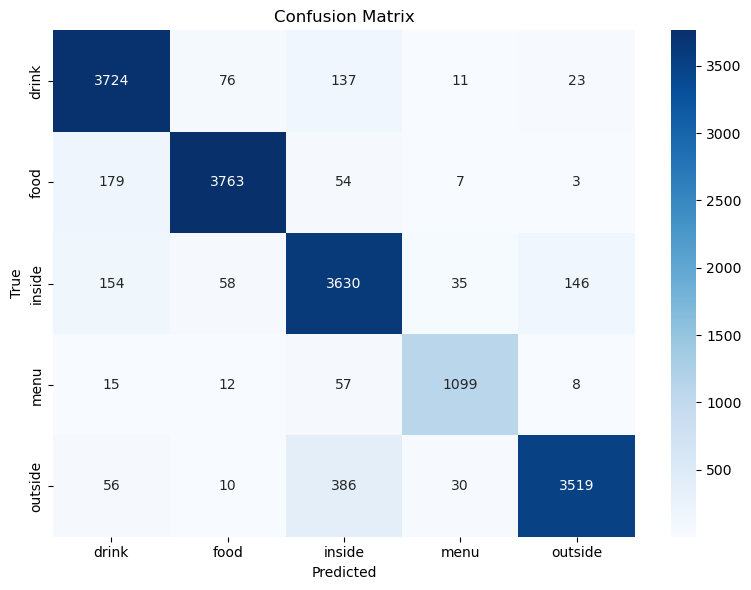


 Classification Report:
              precision    recall  f1-score   support

       drink     0.9021    0.9378    0.9196      3971
        food     0.9602    0.9393    0.9497      4006
      inside     0.8513    0.9023    0.8761      4023
        menu     0.9298    0.9228    0.9263      1191
     outside     0.9513    0.8795    0.9140      4001

    accuracy                         0.9153     17192
   macro avg     0.9190    0.9163    0.9171     17192
weighted avg     0.9171    0.9153    0.9156     17192



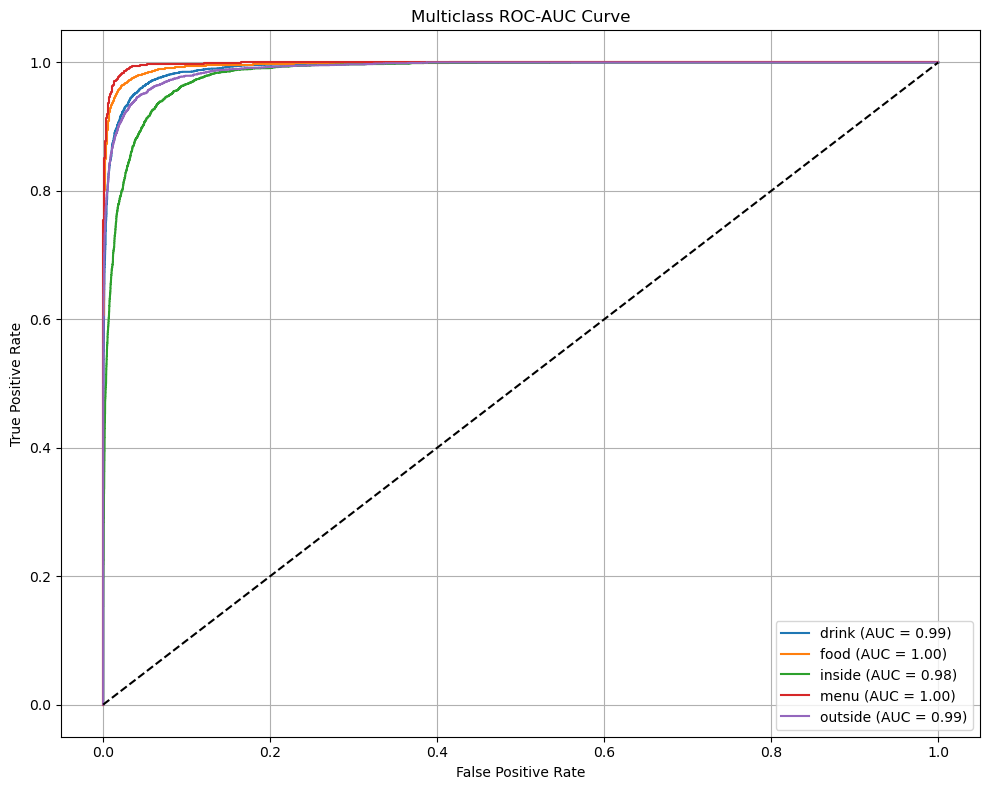

In [52]:
all_preds, all_labels= evaluate(
    model,
    train_loader,
    criterion,
    device=device,
    num_classes=5,
    class_names=['drink', 'food', 'inside', 'menu', 'outside']
)


 Evaluation — Loss: 0.2791, Acc: 0.9045, Recall: 0.9027


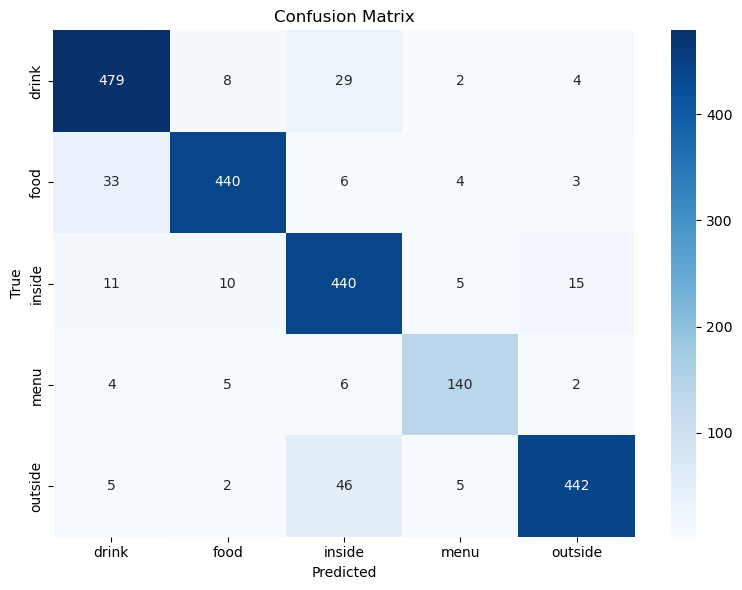


 Classification Report:
              precision    recall  f1-score   support

       drink     0.9004    0.9176    0.9089       522
        food     0.9462    0.9053    0.9253       486
      inside     0.8349    0.9148    0.8730       481
        menu     0.8974    0.8917    0.8946       157
     outside     0.9485    0.8840    0.9151       500

    accuracy                         0.9045      2146
   macro avg     0.9055    0.9027    0.9034      2146
weighted avg     0.9071    0.9045    0.9050      2146



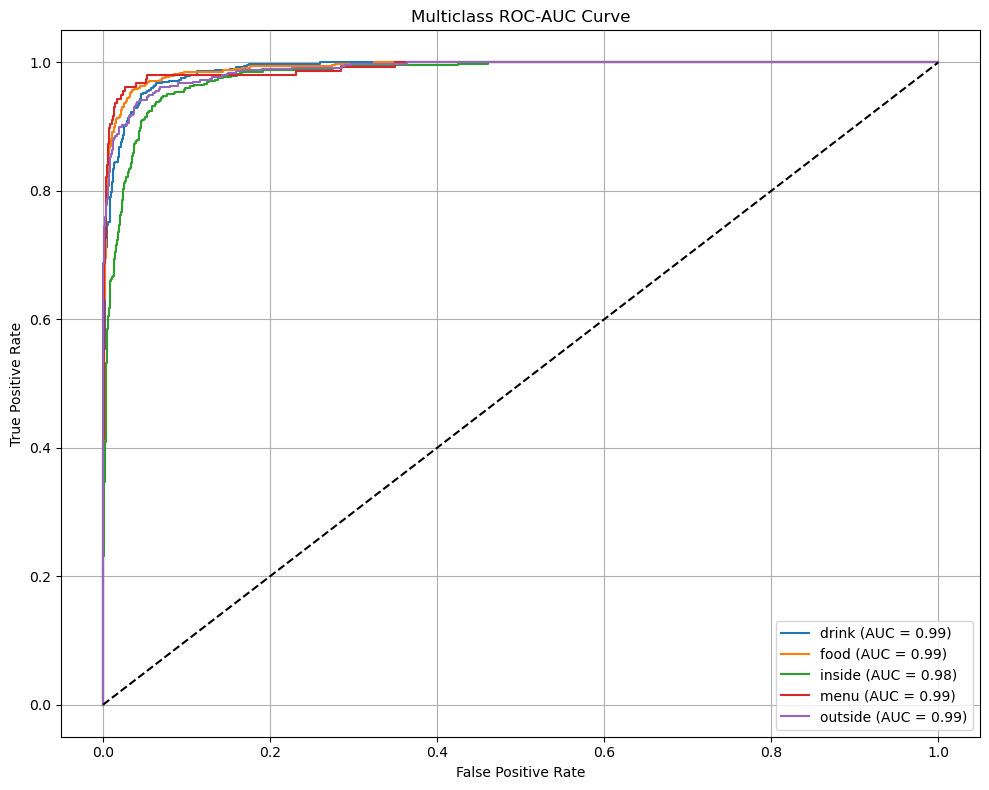

In [ ]:
all_preds, all_labels= evaluate(
    model,
    val_loader,
    criterion,
    device=device,
    num_classes=5,
    class_names=['drink', 'food', 'inside', 'menu', 'outside']
)

In [14]:
# === Load and clean metadata
df_val = pd.read_csv("test_metadata.csv")
df_val = clean_dataframe_of_missing_images(df_val, 'split_photos/test')

transform = get_transforms()

# === Build dataset and dataloader
test_dataset = ImageDFDataset(df_val, image_dir='split_photos/test', transform=transform)
test_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

criterion = nn.CrossEntropyLoss()

Checking image validity: 100%|██████████| 2150/2150 [00:12<00:00, 174.40it/s]


✔️ Cleaned DataFrame: 2149 valid | 1 missing | 0 corrupt



 Evaluation — Loss: 0.2797, Acc: 0.9045, Recall: 0.9027


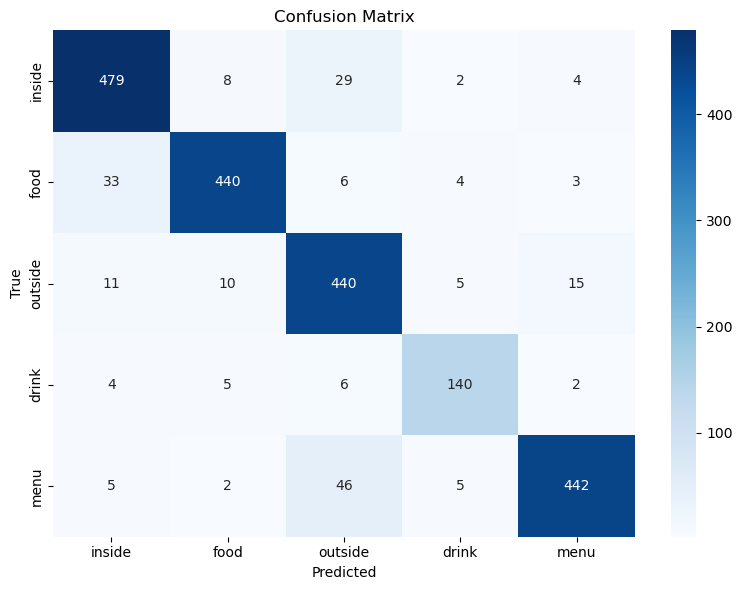


 Classification Report:
              precision    recall  f1-score   support

      inside     0.9004    0.9176    0.9089       522
        food     0.9462    0.9053    0.9253       486
     outside     0.8349    0.9148    0.8730       481
       drink     0.8974    0.8917    0.8946       157
        menu     0.9485    0.8840    0.9151       500

    accuracy                         0.9045      2146
   macro avg     0.9055    0.9027    0.9034      2146
weighted avg     0.9071    0.9045    0.9050      2146



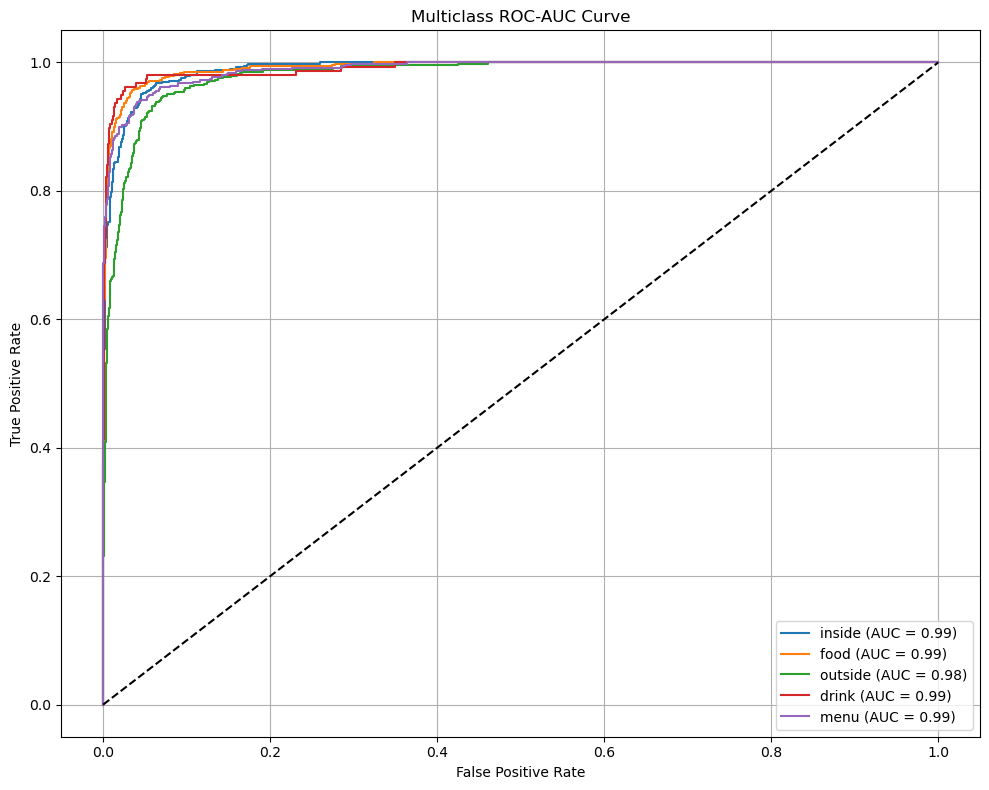

In [ ]:
all_preds, all_labels= evaluate(
    model,
    test_loader,
    criterion,
    device=device,
    num_classes=5,
    class_names=['drink', 'food', 'inside', 'menu', 'outside']
)

## Fine Tunning 

In [16]:
def fine_tune_vgg_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(" Fine-tuning on:", device)

    transform = get_transforms()

    # Load metadata
    df_train = pd.read_csv('train_augmented_metadata.csv', low_memory=False)
    df_val   = pd.read_csv("val_metadata.csv")
    df_test  = pd.read_csv("test_metadata.csv")

    # Clean missing/corrupt images
    df_train = clean_dataframe_of_missing_images(df_train, 'augmented_photos/train')
    df_val   = clean_dataframe_of_missing_images(df_val, 'split_photos/val')
    df_test  = clean_dataframe_of_missing_images(df_test, 'split_photos/test')

    # Datasets and Loaders
    train_dataset, val_dataset, test_dataset = get_datasets(df_train, df_val, df_test, transform)
    train_loader, val_loader, test_loader = get_dataloaders(train_dataset, val_dataset, test_dataset)

    # Load model and weights
    model = build_model(num_classes=5, device=device)
    model.load_state_dict(torch.load("best_vgg_classifier_only.pth", map_location=device))

    # === Print trainable parameters before unfreezing ===
    initial_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f" Trainable parameters BEFORE unfreezing: {initial_trainable:,}")

    # === Unfreeze selected layers ===
    for param in model.features[-8:].parameters():  # unfreeze last conv block
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True  # unfreeze classifier

    # === Print trainable parameters after unfreezing ===
    updated_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f" Trainable parameters AFTER unfreezing: {updated_trainable:,}")

    print(' Fine Tune model architecture:')
    print(model)

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    # === Train the fine-tuned model ===
    model = train_one_phase(model, train_loader, val_loader, criterion, optimizer, device)

    torch.save(model.state_dict(), "vgg_finetuned.pth")
    print(" Fine-tuned model saved as vgg_finetuned.pth")


In [17]:
if __name__ == '__main__':
    
    fine_tune_vgg_model()

 Fine-tuning on: cuda


Checking image validity: 100%|██████████| 17192/17192 [00:07<00:00, 2393.81it/s]


✔️ Cleaned DataFrame: 17192 valid | 0 missing | 0 corrupt


Checking image validity: 100%|██████████| 2150/2150 [00:00<00:00, 2495.23it/s]


✔️ Cleaned DataFrame: 2146 valid | 4 missing | 0 corrupt


...

Epoch 2: Val Loss = 0.2678, Val Acc = 0.9208


Epoch 3: Val Loss = 0.4044, Val Acc = 0.9059


Epoch 4: Val Loss = 0.4643, Val Acc = 0.9105


Epoch 5: Val Loss = 0.6615, Val Acc = 0.9003


Epoch 6: Val Loss = 0.5191, Val Acc = 0.9161
 Early stopping triggered!
 Best model restored.
 Fine-tuned model saved as vgg_finetuned.pth


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Rebuild the same architecture
model = build_model(num_classes=5, device=device)

# Load trained weights
model.load_state_dict(torch.load("vgg_finetuned.pth", map_location=device))

# Optional: verify model is on right device
model = model.to(device)

In [19]:
# === Load and clean metadata
df_val = pd.read_csv("val_metadata.csv")
df_val = clean_dataframe_of_missing_images(df_val, 'split_photos/val')

transform = get_transforms()

# === Build dataset and dataloader
val_dataset = ImageDFDataset(df_val, image_dir='split_photos/val', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

criterion = nn.CrossEntropyLoss()

Checking image validity: 100%|██████████| 2150/2150 [00:00<00:00, 2602.65it/s]

✔️ Cleaned DataFrame: 2146 valid | 4 missing | 0 corrupt



 Evaluation — Loss: 0.2327, Acc: 0.9199, Recall: 0.9079


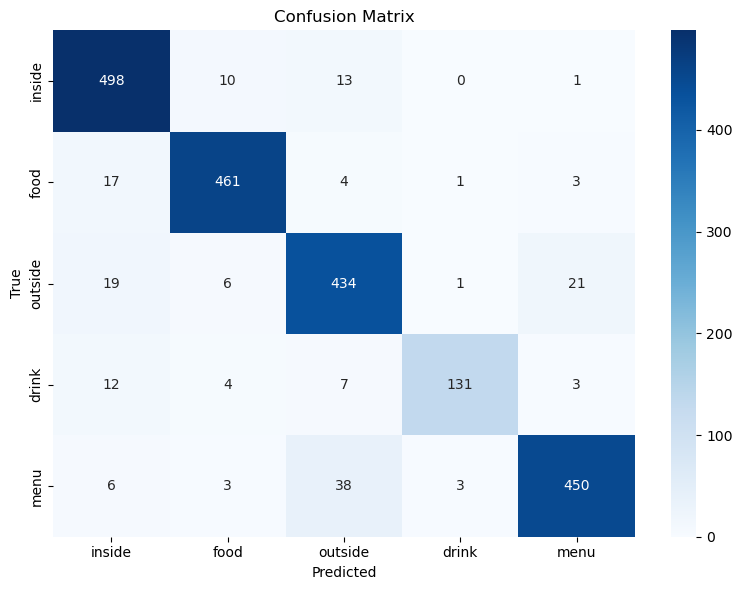


 Classification Report:
              precision    recall  f1-score   support

      inside     0.9022    0.9540    0.9274       522
        food     0.9525    0.9486    0.9505       486
     outside     0.8750    0.9023    0.8884       481
       drink     0.9632    0.8344    0.8942       157
        menu     0.9414    0.9000    0.9202       500

    accuracy                         0.9199      2146
   macro avg     0.9269    0.9079    0.9162      2146
weighted avg     0.9211    0.9199    0.9198      2146



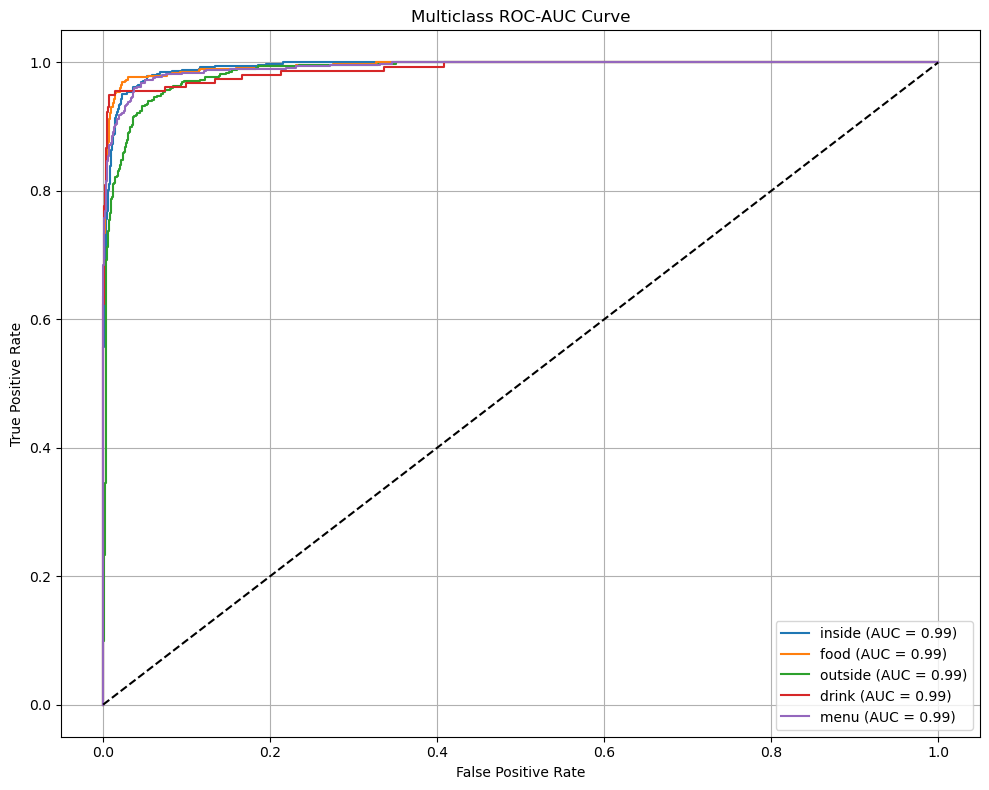

In [ ]:
all_preds, all_labels= evaluate(
    model,
    val_loader,
    criterion,
    device=device,
    num_classes=5,
    class_names=['drink', 'food', 'inside', 'menu', 'outside']
)

In [21]:
# === Load and clean metadata
df_test = pd.read_csv("test_metadata.csv")
df_test = clean_dataframe_of_missing_images(df_test, 'split_photos/test')

transform = get_transforms()

# === Build dataset and dataloader
test_dataset = ImageDFDataset(df_test, image_dir='split_photos/test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

criterion = nn.CrossEntropyLoss()

Checking image validity: 100%|██████████| 2150/2150 [00:13<00:00, 164.25it/s]

✔️ Cleaned DataFrame: 2149 valid | 1 missing | 0 corrupt



 Evaluation — Loss: 0.2214, Acc: 0.9251, Recall: 0.9144


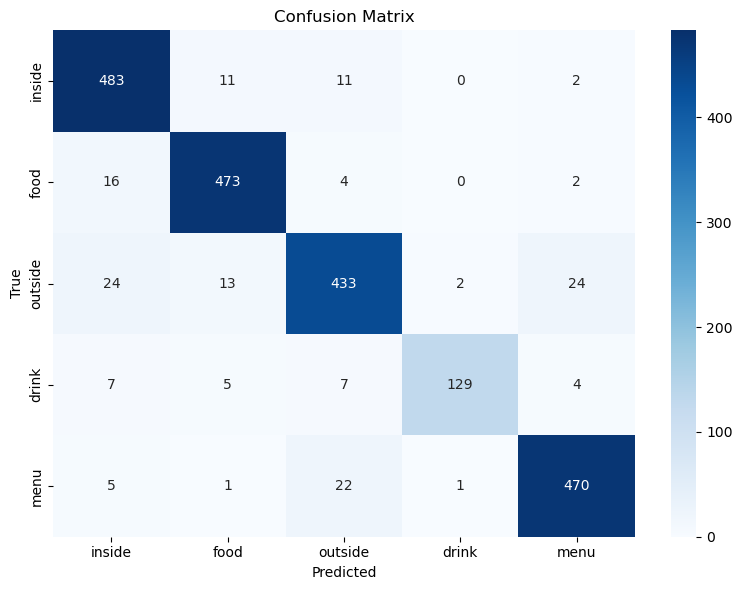


 Classification Report:
              precision    recall  f1-score   support

      inside     0.9028    0.9527    0.9271       507
        food     0.9404    0.9556    0.9479       495
     outside     0.9078    0.8730    0.8900       496
       drink     0.9773    0.8487    0.9085       152
        menu     0.9363    0.9419    0.9391       499

    accuracy                         0.9251      2149
   macro avg     0.9329    0.9144    0.9225      2149
weighted avg     0.9256    0.9251    0.9248      2149



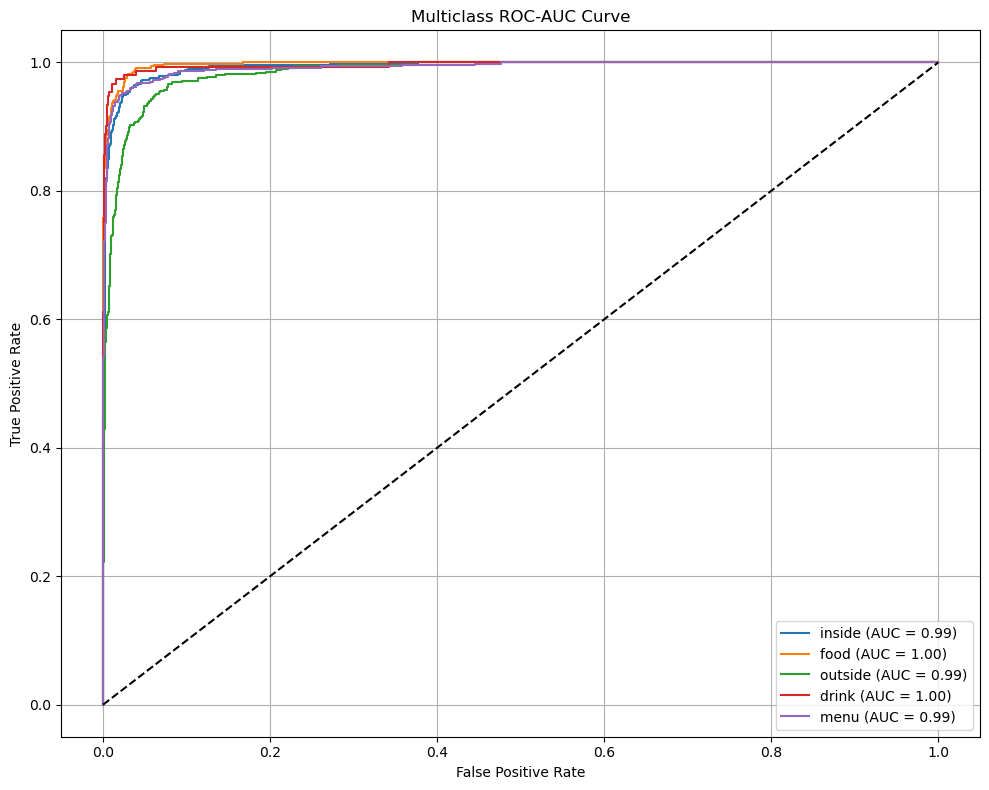

In [ ]:
all_preds, all_labels= evaluate(
    model,
    test_loader,
    criterion,
    device=device,
    num_classes=5,
    class_names=['drink', 'food', 'inside', 'menu', 'outside']
)

### 🛠️ 1st Round of Tuning — Issues Faced and Fixes


- **Fix**: Unfroze last convolutional block (conv5_x) and trained with lr=1e-4.
- **Result**: Improved slightly on validation accuracy and F1, especially for dominant classes like food and outside.


## LIME

In [23]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import numpy as np
import torch.nn.functional as F


In [75]:
# ✅ STEP 2: Load Fine-Tuned Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_model(num_classes, device):
    model = models.vgg16(weights='DEFAULT')
    model.classifier[6] = torch.nn.Linear(4096, num_classes)
    return model.to(device)

# Load model and weights
model = build_model(num_classes=5, device=device)
model.load_state_dict(torch.load("vgg_finetuned.pth", map_location=device))
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [76]:
# ✅ STEP 3: Define Preprocessing Function for LIME
lime_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def lime_predict(images_np):
    model.eval()
    batch = torch.stack([
        lime_transform(Image.fromarray(img.astype('uint8')).convert('RGB'))
        for img in images_np
    ])
    batch = batch.to(device)
    with torch.no_grad():
        outputs = model(batch)
        probs = F.softmax(outputs, dim=1)
    return probs.cpu().numpy()


In [81]:
# ✅ STEP 4: Select a Test Image
df_test = pd.read_csv("test_metadata.csv")
photo_id = df_test['photo_id'].iloc[20]  # or manually set: photo_id = 'tS1d3bLP8oWUMzFxCWKgYg'
img_path = f"split_photos/test/{photo_id}.jpg"

image_np = np.array(Image.open(img_path).convert('RGB'))

# ✅ STEP 5: Run LIME Explanation
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image_np,
    classifier_fn=lime_predict,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)


  0%|          | 0/1000 [00:00<?, ?it/s]

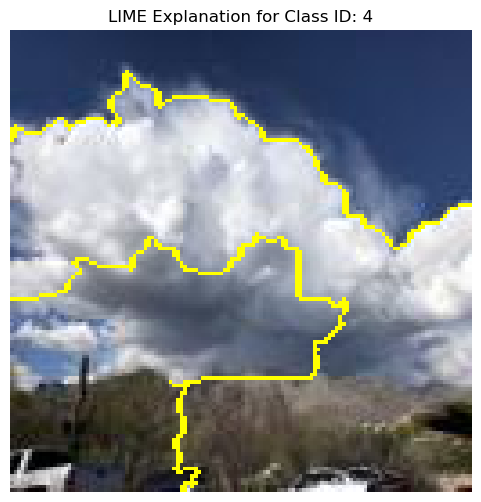

In [82]:
# ✅ STEP 6: Visualize LIME Output
top_label = explanation.top_labels[0]
img, mask = explanation.get_image_and_mask(
    top_label,
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(img / 255.0, mask))
plt.title(f"LIME Explanation for Class ID: {top_label}")
plt.axis('off')
plt.show()

In [83]:
class_names = ['drink', 'food', 'inside', 'menu', 'outside']
print("Predicted class:", class_names[top_label])


Predicted class: outside


In [84]:
# To print top prediction and its confidence
output = model(lime_transform(Image.fromarray(image_np).convert("RGB")).unsqueeze(0).to(device))
probs = F.softmax(output, dim=1)
pred_idx = torch.argmax(probs).item()

print(f"Predicted Class: {class_names[pred_idx]}")
print(f"Confidence: {probs[0][pred_idx].item() * 100:.2f}%")


Predicted Class: outside
Confidence: 99.99%


### An image was passed through the fine-tuned model.
### LIME highlighted the regions (superpixels) that contributed positively to the predicted class.
### It also showed the top class predicted and its confidence level.

# Fine Tuning 2

### In first fine tuning unfroze layers 

In [43]:
def second_fine_tune_vgg_model():
    import torch
    import pandas as pd
    from torch import nn
    from torch.optim import Adam

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("🔁 Second Fine-tuning on:", device)

    # 1. Get transforms
    transform = get_transforms()

    # 2. Load metadata
    df_train = pd.read_csv('train_augmented_metadata.csv')
    df_val   = pd.read_csv("val_metadata.csv")
    df_test  = pd.read_csv("test_metadata.csv")

    # 3. Clean missing/corrupt images
    df_train = clean_dataframe_of_missing_images(df_train, 'augmented_photos/train')
    df_val   = clean_dataframe_of_missing_images(df_val, 'split_photos/val')
    df_test  = clean_dataframe_of_missing_images(df_test, 'split_photos/test')

    # 4. Prepare datasets and loaders
    train_dataset, val_dataset, test_dataset = get_datasets(df_train, df_val, df_test, transform)
    train_loader, val_loader, test_loader = get_dataloaders(train_dataset, val_dataset, test_dataset)

    # 5. Load base model and weights from 1st fine-tune
    model = build_model(num_classes=5, device=device)
    model.load_state_dict(torch.load("vgg_finetuned.pth", map_location=device))

    # 6. Freeze most layers, unfreeze conv4_x + conv5_x
    print("🔒 Trainable params BEFORE unfreezing:", sum(p.numel() for p in model.parameters() if p.requires_grad))
    
    for param in model.features[:16]:  # freeze all except conv4_x + conv5_x
        for p in param.parameters():
            p.requires_grad = False

    for param in model.features[16:]:  # conv4_1 onwards
        for p in param.parameters():
            p.requires_grad = True

    for p in model.classifier.parameters():
        p.requires_grad = True

    print("🔓 Trainable params AFTER unfreezing:", sum(p.numel() for p in model.parameters() if p.requires_grad))

    # 7. Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

    # 8. Train
    model = train_one_phase(model, train_loader, val_loader, criterion, optimizer, device)

    # 9. Save model
    torch.save(model.state_dict(), "vgg_finetuned_round2.pth")
    print("✅ Model saved as vgg_finetuned_round2.pth")

    # 10. Return everything needed
    return model, test_loader, criterion


🔁 Second Fine-tuning on: cuda


Checking image validity: 100%|██████████| 17192/17192 [01:51<00:00, 154.78it/s]


✔️ Cleaned DataFrame: 17192 valid | 0 missing | 0 corrupt


Checking image validity: 100%|██████████| 2150/2150 [00:01<00:00, 1377.83it/s]


✔️ Cleaned DataFrame: 2146 valid | 4 missing | 0 corrupt


...

Epoch 2: Val Loss = 0.3307, Val Acc = 0.9250


Epoch 3: Val Loss = 0.3561, Val Acc = 0.9264


Epoch 4: Val Loss = 0.4385, Val Acc = 0.9254


Epoch 5: Val Loss = 0.4646, Val Acc = 0.9226


Epoch 6: Val Loss = 0.4922, Val Acc = 0.9226
 Early stopping triggered!
 Best model restored.
✅ Model saved as vgg_finetuned_round2.pth

 Evaluation — Loss: 0.2229, Acc: 0.9358, Recall: 0.9336


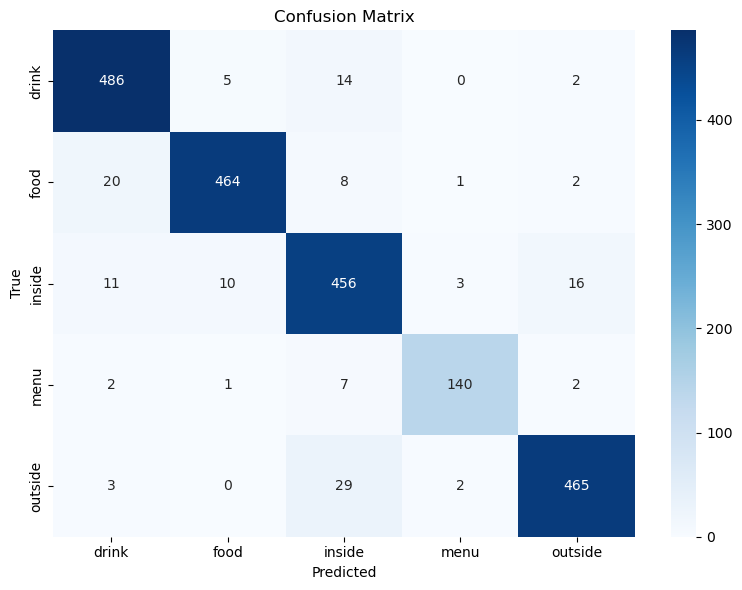


 Classification Report:
              precision    recall  f1-score   support

       drink     0.9310    0.9586    0.9446       507
        food     0.9667    0.9374    0.9518       495
      inside     0.8872    0.9194    0.9030       496
        menu     0.9589    0.9211    0.9396       152
     outside     0.9548    0.9319    0.9432       499

    accuracy                         0.9358      2149
   macro avg     0.9397    0.9336    0.9364      2149
weighted avg     0.9366    0.9358    0.9360      2149



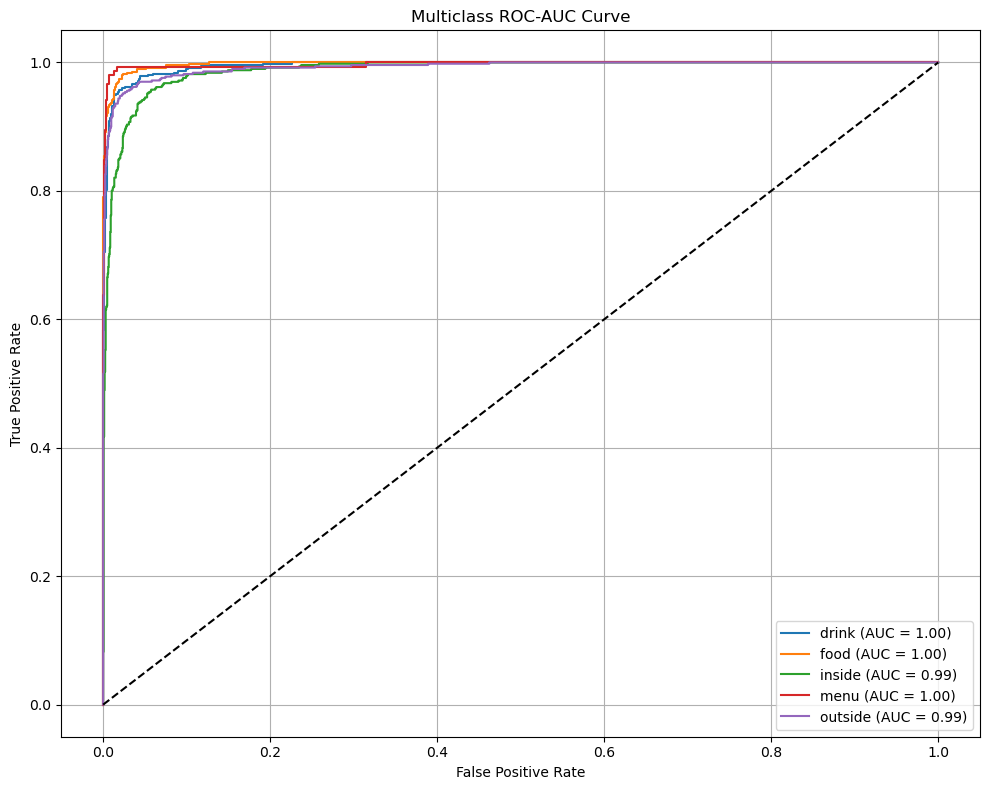

([2,
  0,
  1,
  4,
  3,
  2,
  4,
  0,
  1,
  0,
  1,
  3,
  0,
  4,
  4,
  2,
  1,
  2,
  1,
  2,
  4,
  1,
  1,
  2,
  0,
  1,
  4,
  1,
  0,
  0,
  1,
  1,
  4,
  0,
  0,
  1,
  2,
  1,
  3,
  4,
  2,
  0,
  1,
  0,
  1,
  3,
  1,
  4,
  3,
  2,
  0,
  1,
  3,
  2,
  0,
  2,
  3,
  2,
  1,
  1,
  4,
  1,
  2,
  1,
  3,
  1,
  3,
  0,
  4,
  0,
  0,
  2,
  1,
  4,
  0,
  2,
  2,
  1,
  2,
  1,
  1,
  2,
  3,
  0,
  0,
  2,
  1,
  4,
  0,
  0,
  2,
  0,
  1,
  4,
  4,
  0,
  2,
  1,
  0,
  4,
  2,
  4,
  4,
  3,
  2,
  3,
  0,
  2,
  0,
  0,
  0,
  4,
  2,
  2,
  1,
  4,
  4,
  2,
  2,
  0,
  4,
  1,
  0,
  0,
  3,
  1,
  1,
  2,
  2,
  1,
  2,
  2,
  4,
  4,
  0,
  1,
  4,
  0,
  0,
  2,
  0,
  4,
  1,
  0,
  2,
  0,
  1,
  4,
  4,
  4,
  4,
  0,
  3,
  2,
  2,
  2,
  2,
  0,
  0,
  0,
  4,
  2,
  2,
  3,
  1,
  1,
  2,
  1,
  2,
  0,
  1,
  1,
  2,
  2,
  4,
  4,
  2,
  0,
  0,
  2,
  1,
  2,
  0,
  0,
  0,
  2,
  2,
  4,
  1,
  3,
  2,
  1,
  0,
  2,
  4,
  1,
  1,
  2,
  2,
  2,


In [45]:
model, test_loader, criterion = second_fine_tune_vgg_model()

evaluate(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    num_classes=5,
    class_names=['drink', 'food', 'inside', 'menu', 'outside']
)


### 🛠️ 2nd Round of Tuning — Issues Faced and Fixes

- **Issue**: LIME revealed that the model often focused on irrelevant areas.
- **Fix**: Unfroze additional mid-level layers (conv4_x + conv5_x), reduced learning rate to 1e-5 for stable updates.
- **Result**: Model focused more precisely on task-relevant image regions. Performance improved on minority classes and visual explanations were more trustworthy.


| Tuning Stage | Layers Unfrozen          | Learning Rate | Key Improvement                          |
|--------------|---------------------------|----------------|-------------------------------------------|
| 1st Tuning   | `conv5_x`, classifier     | 1e-4          | Basic adaptation, modest accuracy boost   |
| 2nd Tuning   | `conv4_x + conv5_x`, classifier | 1e-5    | Better focus, stronger interpretability   |


# Lime Interpretability

In [65]:
# Match VGG preprocessing
lime_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def lime_predict(images_np):
    model.eval()
    batch = torch.stack([
        lime_transform(Image.fromarray(img.astype('uint8')).convert('RGB'))
        for img in images_np
    ])
    batch = batch.to(device)
    with torch.no_grad():
        outputs = model(batch)
        probs = F.softmax(outputs, dim=1)
    return probs.cpu().numpy()


In [71]:
import pandas as pd

# Get test image ID
df_test = pd.read_csv("test_metadata.csv")
photo_id = df_test['photo_id'].iloc[20]  # or choose manually
img_path = f"split_photos/test/{photo_id}.jpg"
image_np = np.array(Image.open(img_path).convert('RGB'))


  0%|          | 0/1000 [00:00<?, ?it/s]

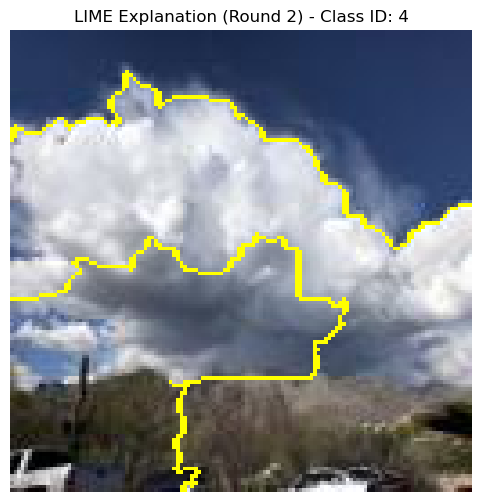

Predicted class: outside


In [72]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image_np,
    classifier_fn=lime_predict,
    top_labels=5,
    hide_color=0,
    num_samples=1000
)

# Visualize explanation for top predicted class
top_label = explanation.top_labels[0]
img, mask = explanation.get_image_and_mask(
    top_label,
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(img / 255.0, mask))
plt.title(f"LIME Explanation (Round 2) - Class ID: {top_label}")
plt.axis('off')
plt.show()

class_names = ['drink', 'food', 'inside', 'menu', 'outside']
print("Predicted class:", class_names[top_label])



In [73]:
# To print top prediction and its confidence
output = model(lime_transform(Image.fromarray(image_np).convert("RGB")).unsqueeze(0).to(device))
probs = F.softmax(output, dim=1)
pred_idx = torch.argmax(probs).item()

print(f"Predicted Class: {class_names[pred_idx]}")
print(f"Confidence: {probs[0][pred_idx].item() * 100:.2f}%")


Predicted Class: outside
Confidence: 99.89%
